# **TSA - VK - Final II**

**FAAF = TSA**

In [ ]:
#@title Load data
from google.colab import files
data = files.upload()

Saving cylinder_nektar_t0_vorticity.mat to cylinder_nektar_t0_vorticity.mat
Saving cylinder_nektar_wake.mat to cylinder_nektar_wake.mat


In [ ]:
import tensorflow as tf
import numpy as np
from scipy.io import loadmat
import scipy.io

# Ensure consistent data types across the entire code
dtype = tf.float64

Re = tf.constant(100, dtype=dtype)

# Define number of points for residuals and boundary conditions
N_train_residuals = 1200  # Number of points for residuals
N_train_bcs = 1200  # Number of points for boundary conditions

layers = [3, 51, 51, 51, 51, 3]

# Load Data
data = scipy.io.loadmat('/content/cylinder_nektar_wake.mat')

U_star = data['U_star']  # N x 2 x T
P_star = data['p_star']  # N x T
t_star = data['t']  # is the very last time frame
X_star = data['X_star']  # N x 2

N = X_star.shape[0]  # total number of available data (Spatial) for training and test
T = t_star.shape[0]  # total number of available data (Temporal) for training and test

# Rearrange Data (Total Data)
XX = np.tile(X_star[:, 0:1], (1, T))  # N x T
YY = np.tile(X_star[:, 1:2], (1, T))  # N x T
TT = np.tile(t_star, (1, N)).T  # N x T

UU = U_star[:, 0, :]  # N x T
VV = U_star[:, 1, :]  # N x T
PP = P_star  # N x T

x = XX.flatten()[:, None]  # NT x 1
y = YY.flatten()[:, None]  # NT x 1
t = TT.flatten()[:, None]  # NT x 1

u = UU.flatten()[:, None]  # NT x 1
v = VV.flatten()[:, None]  # NT x 1
p = PP.flatten()[:, None]  # NT x 1

# Training Data
# Sample indices for residuals and boundary conditions separately
idx_residuals = np.random.choice(N * T, N_train_residuals, replace=False)
idx_bcs = np.random.choice(N * T, N_train_bcs, replace=False)

x_train_residuals = x[idx_residuals, :]
y_train_residuals = y[idx_residuals, :]
t_train_residuals = t[idx_residuals, :]
u_train_residuals = u[idx_residuals, :]
v_train_residuals = v[idx_residuals, :]
p_train_residuals = p[idx_residuals, :]

x_train_bcs = x[idx_bcs, :]
y_train_bcs = y[idx_bcs, :]
t_train_bcs = t[idx_bcs, :]
u_train_bcs = u[idx_bcs, :]
v_train_bcs = v[idx_bcs, :]
p_train_bcs = p[idx_bcs, :]

# Ensure all initial tensors for training have dtype=tf.float64
x_train_residuals = tf.convert_to_tensor(x_train_residuals, dtype=dtype)
y_train_residuals = tf.convert_to_tensor(y_train_residuals, dtype=dtype)
t_train_residuals = tf.convert_to_tensor(t_train_residuals, dtype=dtype)
u_train_residuals = tf.convert_to_tensor(u_train_residuals, dtype=dtype)
v_train_residuals = tf.convert_to_tensor(v_train_residuals, dtype=dtype)
p_train_residuals = tf.convert_to_tensor(p_train_residuals, dtype=dtype)

x_train_bcs = tf.convert_to_tensor(x_train_bcs, dtype=dtype)
y_train_bcs = tf.convert_to_tensor(y_train_bcs, dtype=dtype)
t_train_bcs = tf.convert_to_tensor(t_train_bcs, dtype=dtype)
u_train_bcs = tf.convert_to_tensor(u_train_bcs, dtype=dtype)
v_train_bcs = tf.convert_to_tensor(v_train_bcs, dtype=dtype)
p_train_bcs = tf.convert_to_tensor(p_train_bcs, dtype=dtype)

# print the shapes of bcs data
print("x_train_bcs shape:", x_train_bcs.shape)
print("y_train_bcs shape:", y_train_bcs.shape)
print("t_train_bcs shape:", t_train_bcs.shape)
print("u_train_bcs shape:", u_train_bcs.shape)
print("v_train_bcs shape:", v_train_bcs.shape)
print("p_train_bcs shape:", p_train_bcs.shape)

print("x_train_residuals shape:", x_train_residuals.shape)
print("y_train_residuals shape:", y_train_residuals.shape)
print("t_train_residuals shape:", t_train_residuals.shape)

x_train_bcs shape: (1200, 1)
y_train_bcs shape: (1200, 1)
t_train_bcs shape: (1200, 1)
u_train_bcs shape: (1200, 1)
v_train_bcs shape: (1200, 1)
p_train_bcs shape: (1200, 1)
x_train_residuals shape: (1200, 1)
y_train_residuals shape: (1200, 1)
t_train_residuals shape: (1200, 1)


Epoch 0, Loss: 1.2372819038607703, Data Mismatch Loss: 1.1788683726793114, Physics-informed Loss: 0.058413531181458776 L2 Error: 0.6437031357916572
Epoch 100, Loss: 0.2690563201733101, Data Mismatch Loss: 0.2662422145750734, Physics-informed Loss: 0.0028141055982367122 L2 Error: 0.36308198181118645
Epoch 200, Loss: 0.23171887481125458, Data Mismatch Loss: 0.22504802932483628, Physics-informed Loss: 0.006670845486418309 L2 Error: 0.3308688419493458
Epoch 300, Loss: 0.2143341680733708, Data Mismatch Loss: 0.2047135928423651, Physics-informed Loss: 0.009620575231005714 L2 Error: 0.3168013821978621
Epoch 400, Loss: 0.20560882692853924, Data Mismatch Loss: 0.19505474957915606, Physics-informed Loss: 0.010554077349383195 L2 Error: 0.310243167973555
Epoch 500, Loss: 0.19963450143047423, Data Mismatch Loss: 0.18838520743706869, Physics-informed Loss: 0.011249293993405532 L2 Error: 0.30906402591423066
Epoch 600, Loss: 0.19839096079032503, Data Mismatch Loss: 0.18690011741815307, Physics-informe

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:664: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 0, Loss: 1.131419171403662, Data Mismatch Loss: 0.9052098155124535, Physics-informed Loss: 1.3822187982931352e-09, reg_term: 4.420683672302591 L2 Error: 0.6628029603391992
Epoch 100, Loss: 0.3218666001460533, Data Mismatch Loss: 0.14889094478504372, Physics-informed Loss: 0.00019021873584434412, reg_term: 5.787524802621911 L2 Error: 0.28343908608273244
Epoch 200, Loss: 0.2849506181459036, Data Mismatch Loss: 0.14677033925503866, Physics-informed Loss: 1.831220530540118e-05, reg_term: 7.237881914896905 L2 Error: 0.2806265905767136
Epoch 300, Loss: 0.20513059130475592, Data Mismatch Loss: 0.09946421942684767, Physics-informed Loss: 0.001535200584243352, reg_term: 9.603272368653723 L2 Error: 0.22345491713462118
Epoch 400, Loss: 0.16985114807894286, Data Mismatch Loss: 0.0916595125029861, Physics-informed Loss: 0.001392881290186514, reg_term: 13.021044537766493 L2 Error: 0.21951095979642082
Epoch 500, Loss: 0.14792545742541433, Data Mismatch Loss: 0.09025735311598618, Physics-informe

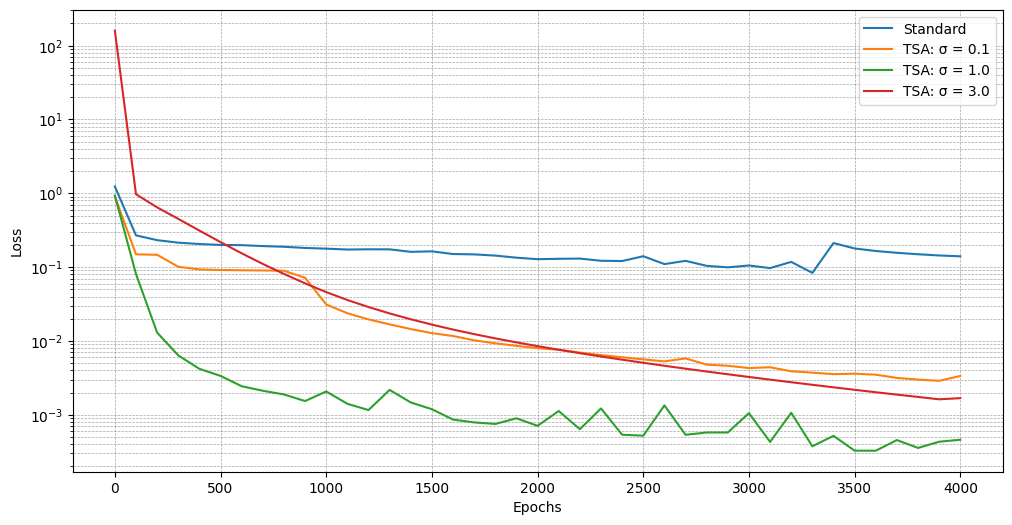

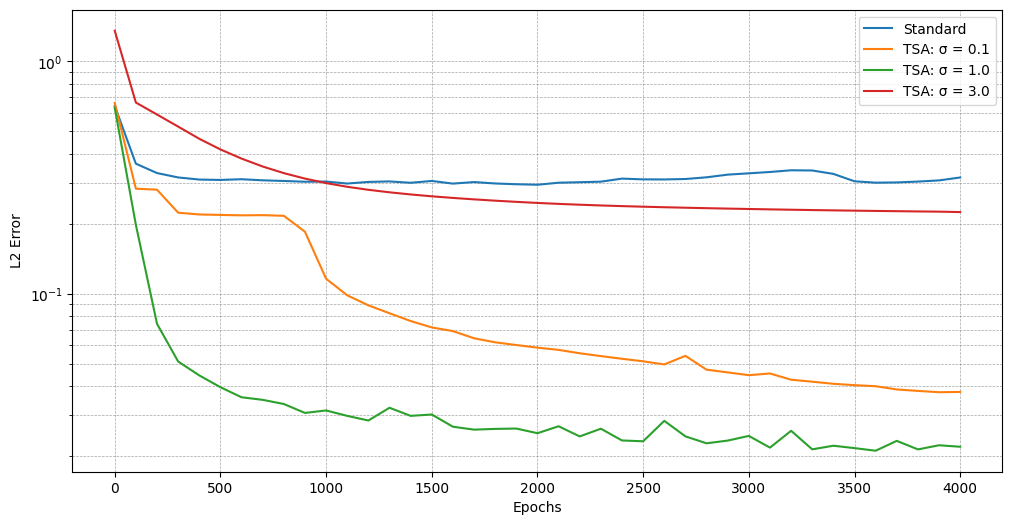

In [ ]:
#@title FAAF: Trainable (Computational Graph)
from os import uname
#@title FAAF: Trainable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from time import time

dtype = tf.float64  # Ensure all tensors use this dtype
layers = [3, 50, 50, 50, 2]  # Adjust the input and output layer dimensions
# Xavier initialization function
def xavier_init(size):
    in_dim, out_dim = size
    xavier_stddev = np.sqrt(2 / (in_dim + out_dim))
    return tf.Variable(tf.random.normal([in_dim, out_dim], stddev=xavier_stddev, dtype=dtype), dtype=dtype)

def initialize_NN_standard(layers):
    weights = []
    biases = []
    num_layers = len(layers)
    for l in range(num_layers - 1):
        W = xavier_init([layers[l], layers[l + 1]])
        b = tf.Variable(tf.zeros([1, layers[l + 1]], dtype=dtype), dtype=dtype)
        weights.append(W)
        biases.append(b)
    return weights, biases

################################################################################################################################################### Standard
def forward_pass_standard(H, weights, biases):
    for l in range(len(weights)):
        W = weights[l]
        b = biases[l]
        H = tf.tanh(tf.matmul(H, W) + b)
    return H

optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
weights, biases = initialize_NN_standard(layers)

def operator(input, outputs, weights, biases):
    with tf.GradientTape(persistent=True) as ggg:
        x = tf.convert_to_tensor(input[:, 0:1], dtype=tf.float64)
        y = tf.convert_to_tensor(input[:, 1:2], dtype=tf.float64)
        t = tf.convert_to_tensor(input[:, 2:3], dtype=tf.float64)
        ggg.watch(x)
        ggg.watch(y)
        ggg.watch(t)
        with tf.GradientTape(persistent=True) as gg:
            gg.watch(x)
            gg.watch(y)
            gg.watch(t)
            with tf.GradientTape(persistent=True) as g:
                g.watch(x)
                g.watch(y)
                g.watch(t)
                psi_p = forward_pass_standard(tf.stack([x[:,0], y[:,0], t[:,0]], axis=1), weights, biases)
                psi = psi_p[..., 0, tf.newaxis]
                p = psi_p[..., 1, tf.newaxis]
            u = g.gradient(psi, y)
            v = -g.gradient(psi, x)
            p_x = g.gradient(p, x)
            p_y = g.gradient(p, y)
        u_x = gg.gradient(u, x)
        u_y = gg.gradient(u, y)
        u_t = gg.gradient(u, t)
        v_x = gg.gradient(v, x)
        v_y = gg.gradient(v, y)
        v_t = gg.gradient(v, t)
    u_xx = ggg.gradient(u_x, x)
    u_yy = ggg.gradient(u_y, y)
    v_xx = ggg.gradient(v_x, x)
    v_yy = ggg.gradient(v_y, y)

    Ru_momentum = u_t + u * u_x + v * u_y + p_x - (u_xx + u_yy) / Re
    Rv_momentum = v_t + u * v_x + v * v_y + p_y - (v_xx + v_yy) / Re

    u_true = outputs[:, 0:1]
    v_true = outputs[:, 1:2]
    predicted_u = u
    predicted_v = v
    loss_res = tf.reduce_mean(tf.square(Ru_momentum) + tf.square(Rv_momentum))
    data_mismatch_loss = tf.reduce_mean(tf.square(predicted_u - u_true) + tf.square(predicted_v - v_true))
    loss = data_mismatch_loss + loss_res
    return Ru_momentum, Rv_momentum, u, v, loss, data_mismatch_loss, loss_res

def error_function(input, outputs_test_true, weights, biases):
  with tf.GradientTape(persistent=True) as g:
    x = tf.convert_to_tensor(input[:, 0:1], dtype=tf.float64)
    y = tf.convert_to_tensor(input[:, 1:2], dtype=tf.float64)
    t = tf.convert_to_tensor(input[:, 2:3], dtype=tf.float64)
    g.watch(x)
    g.watch(y)
    g.watch(t)
    psi_p = forward_pass_standard(tf.stack([x[:,0], y[:,0], t[:,0]], axis=1), weights, biases)
    psi = psi_p[..., 0, tf.newaxis]
    p = psi_p[..., 1, tf.newaxis]
  u = g.gradient(psi, y)
  v = -g.gradient(psi, x)
  y_pred_test = tf.concat([u, v], axis=1)
  l2_error = tf.sqrt(tf.reduce_mean(tf.square(y_pred_test - outputs_test_true)))
  return l2_error

@tf.function
def train_step(inputs_train, outputs_train, weights, biases, optimizer):
    with tf.GradientTape() as tape:
        Ru_momentum, Rv_momentum, u, v, loss, data_mismatch_loss, loss_res = operator(inputs_train, outputs_train, weights, biases)
    grads = tape.gradient(loss, weights + biases)
    optimizer.apply_gradients(zip(grads, weights + biases))
    return loss, data_mismatch_loss, loss_res, Ru_momentum, Rv_momentum, u, v

def train_and_evaluate_standard(layers, x_train_bcs, y_train_bcs, t_train_bcs, u_train_bcs, v_train_bcs, x_train_residuals, y_train_residuals, t_train_residuals, N_train_bcs=1000, epochs=601, eval_steps=100):
    inputs_train = tf.concat([x_train_bcs[:N_train_bcs], y_train_bcs[:N_train_bcs], t_train_bcs[:N_train_bcs]], axis=1)
    outputs_train = tf.concat([u_train_bcs[:N_train_bcs], v_train_bcs[:N_train_bcs]], axis=1)
    inputs_test = tf.concat([x_train_bcs[N_train_bcs:], y_train_bcs[N_train_bcs:], t_train_bcs[N_train_bcs:]], axis=1)
    outputs_test_true = tf.concat([u_train_bcs[N_train_bcs:], v_train_bcs[N_train_bcs:]], axis=1)

    # Initialize histories
    Error_history = []
    Loss_history = []
    Data_Mismatch_History = []
    Physics_Informed_Loss_History = []

    for epoch in range(epochs):
        loss, data_mismatch_loss, loss_res, _, _, _, _ = train_step(inputs_train, outputs_train, weights, biases, optimizer)

        if epoch % eval_steps == 0 or epoch == epochs - 1:
            l2_error = error_function(inputs_test, outputs_test_true, weights, biases)
            # Append results as tensors, convert to numpy after training loop if necessary
            Error_history.append((epoch, l2_error))
            Loss_history.append((epoch, loss))
            Data_Mismatch_History.append(data_mismatch_loss)
            Physics_Informed_Loss_History.append(loss_res)

            tf.print(f"Epoch {epoch}, Loss: {loss}, Data Mismatch Loss: {data_mismatch_loss}, Physics-informed Loss: {loss_res}", f"L2 Error: {l2_error}")

    # Convert histories to numpy outside of @tf.function
    Error_history = [(epoch, l2_error.numpy()) for epoch, l2_error in Error_history]
    Loss_history = [(epoch, loss.numpy()) for epoch, loss in Loss_history]
    return Error_history, Loss_history, [], Data_Mismatch_History, Physics_Informed_Loss_History

# Training models
t0 = time()
Error_history_standard, loss_history_standard, _, St_Data_Mismatch_History, St_Physics_Informed_Loss_History = train_and_evaluate_standard(layers,  x_train_bcs, y_train_bcs, t_train_bcs, u_train_bcs, v_train_bcs,
                                                                      x_train_residuals, y_train_residuals, t_train_residuals, N_train_bcs=1000, epochs=4001)
print(f"Training time for Standard: {time() - t0} seconds")

################################################################################################################################################### FAAF
def hyper_parameters_A(size, Initial_frequency):
    return tf.Variable(tf.constant(Initial_frequency, shape=size, dtype=dtype))  # Ensure dtype is tf.float64

def forward_pass_adaptive(H, freq, weights, biases):
    A = H
    L = len(weights)
    for i in range(L - 1):
        # Perform matrix multiplication and then apply the frequency scaling
        matmul_result = tf.matmul(A, weights[i])

        # Calculate sine and cosine components
        A_sin = tf.sin(freq[i] * matmul_result + biases[i])
        A_cos = tf.cos(freq[i] * matmul_result + biases[i])

        # Combine sine and cosine components
        A = 0.5 * (A_sin + A_cos)

    # Final layer without frequency multiplication, just a linear transformation
    Y = tf.matmul(A, weights[-1]) + biases[-1]
    return Y


def operator2(input, outputs, freq, weights, biases):
    with tf.GradientTape(persistent=True) as ggg:
        x = tf.convert_to_tensor(input[:, 0:1], dtype=tf.float64)
        y = tf.convert_to_tensor(input[:, 1:2], dtype=tf.float64)
        t = tf.convert_to_tensor(input[:, 2:3], dtype=tf.float64)
        ggg.watch(x)
        ggg.watch(y)
        ggg.watch(t)
        with tf.GradientTape(persistent=True) as gg:
            gg.watch(x)
            gg.watch(y)
            gg.watch(t)
            with tf.GradientTape(persistent=True) as g:
                g.watch(x)
                g.watch(y)
                g.watch(t)
                psi_p = forward_pass_adaptive(tf.stack([x[:,0], y[:,0], t[:,0]], axis=1), freq, weights, biases)
                psi = psi_p[..., 0, tf.newaxis]
                p = psi_p[..., 1, tf.newaxis]
            u = g.gradient(psi, y)
            v = -g.gradient(psi, x)
            p_x = g.gradient(p, x)
            p_y = g.gradient(p, y)
        u_x = gg.gradient(u, x)
        u_y = gg.gradient(u, y)
        u_t = gg.gradient(u, t)
        v_x = gg.gradient(v, x)
        v_y = gg.gradient(v, y)
        v_t = gg.gradient(v, t)
    u_xx = ggg.gradient(u_x, x)
    u_yy = ggg.gradient(u_y, y)
    v_xx = ggg.gradient(v_x, x)
    v_yy = ggg.gradient(v_y, y)

    Ru_momentum = u_t + u * u_x + v * u_y + p_x - (u_xx + u_yy) / Re
    Rv_momentum = v_t + u * v_x + v * v_y + p_y - (v_xx + v_yy) / Re

    u_true = outputs[:, 0:1]
    v_true = outputs[:, 1:2]
    predicted_u = u
    predicted_v = v
    loss_res = tf.reduce_mean(tf.square(Ru_momentum) + tf.square(Rv_momentum))
    data_mismatch_loss = tf.reduce_mean(tf.square(predicted_u - u_true) + tf.square(predicted_v - v_true))
    loss = data_mismatch_loss + loss_res
    real_loss = loss
    reg_term = tf.add_n([tf.exp(tf.reduce_mean(freq_i)) for freq_i in freq])
    loss += (1.0 / reg_term)

    return Ru_momentum, Rv_momentum, u, v, loss, data_mismatch_loss, loss_res, real_loss, reg_term

def error_function2(input, outputs_test_true, freq, weights, biases):
  with tf.GradientTape(persistent=True) as g:
    x = tf.convert_to_tensor(input[:, 0:1], dtype=tf.float64)
    y = tf.convert_to_tensor(input[:, 1:2], dtype=tf.float64)
    t = tf.convert_to_tensor(input[:, 2:3], dtype=tf.float64)
    g.watch(x)
    g.watch(y)
    g.watch(t)
    psi_p = forward_pass_adaptive(tf.stack([x[:,0], y[:,0], t[:,0]], axis=1), freq, weights, biases)
    psi = psi_p[..., 0, tf.newaxis]
    p = psi_p[..., 1, tf.newaxis]
  u = g.gradient(psi, y)
  v = -g.gradient(psi, x)
  y_pred_test = tf.concat([u, v], axis=1)
  l2_error = tf.sqrt(tf.reduce_mean(tf.square(y_pred_test - outputs_test_true)))
  return l2_error

@tf.function
def train_step2(inputs_train, outputs_train, freq, weights, biases, optimizer):
    with tf.GradientTape() as tape:
        Ru_momentum, Rv_momentum, u, v, loss, data_mismatch_loss, loss_res, real_loss, reg_term = operator2(inputs_train, outputs_train, freq, weights, biases)
    grads = tape.gradient(loss, weights + biases + freq)
    optimizer.apply_gradients(zip(grads, weights + biases + freq))
    return loss, data_mismatch_loss, loss_res, Ru_momentum, Rv_momentum, u, v, real_loss, reg_term

def train_and_evaluate_FAAF(layers, x_train_bcs, y_train_bcs, t_train_bcs, u_train_bcs, v_train_bcs, x_train_residuals, y_train_residuals, t_train_residuals,
                            freq, weights, biases, optimizer, N_train_bcs=1000, epochs=601, eval_steps=100):
    inputs_train = tf.concat([x_train_bcs[:N_train_bcs], y_train_bcs[:N_train_bcs], t_train_bcs[:N_train_bcs]], axis=1)
    outputs_train = tf.concat([u_train_bcs[:N_train_bcs], v_train_bcs[:N_train_bcs]], axis=1)
    inputs_test = tf.concat([x_train_bcs[N_train_bcs:], y_train_bcs[N_train_bcs:], t_train_bcs[N_train_bcs:]], axis=1)
    outputs_test_true = tf.concat([u_train_bcs[N_train_bcs:], v_train_bcs[N_train_bcs:]], axis=1)

    # Initialize histories
    Error_history = []
    Loss_history = []
    Data_Mismatch_History = []
    Physics_Informed_Loss_History = []
    unameregularized_loss = []

    for epoch in range(epochs):
        loss, data_mismatch_loss, loss_res, _, _, _, _, real_loss, reg_term = train_step2(inputs_train, outputs_train, freq, weights, biases, optimizer)

        if epoch % eval_steps == 0 or epoch == epochs - 1:
            l2_error = error_function2(inputs_test, outputs_test_true, freq, weights, biases)
            # Append results as tensors, convert to numpy after training loop if necessary
            Error_history.append((epoch, l2_error))
            Loss_history.append((epoch, loss))
            Data_Mismatch_History.append(data_mismatch_loss)
            Physics_Informed_Loss_History.append(loss_res)
            unameregularized_loss.append((epoch, real_loss))

            tf.print(f"Epoch {epoch}, Loss: {loss}, Data Mismatch Loss: {data_mismatch_loss}, Physics-informed Loss: {loss_res}, reg_term: {reg_term}", f"L2 Error: {l2_error}")

    # Convert histories to numpy outside of @tf.function
    Error_history = [(epoch, l2_error.numpy()) for epoch, l2_error in Error_history]
    Loss_history = [(epoch, loss.numpy()) for epoch, loss in Loss_history]
    return Error_history, Loss_history, unameregularized_loss, Data_Mismatch_History, Physics_Informed_Loss_History


# Run 1
optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.005)
weights1, biases1 = initialize_NN_standard(layers)
freq1 = [hyper_parameters_A([1, layers[l]], 0.1) for l in range(1, len(layers))]
t0 = time()
Error_history_neuron1, loss_history_neuron1, real_loss_FAAF1, LAAF_Data_Mismatch_History1, LAAF_Physics_Informed_Loss_History1 = train_and_evaluate_FAAF(layers,
      x_train_bcs, y_train_bcs, t_train_bcs, u_train_bcs, v_train_bcs, x_train_residuals, y_train_residuals, t_train_residuals, freq1, weights1, biases1, optimizer1, N_train_bcs=1000, epochs=4001)
print(f"Training time for TSA with σ = 0.1 is: {time() - t0} seconds")

# Run 2
@tf.function
def train_step2(inputs_train, outputs_train, freq, weights, biases, optimizer):
    with tf.GradientTape() as tape:
        Ru_momentum, Rv_momentum, u, v, loss, data_mismatch_loss, loss_res, real_loss, reg_term = operator2(inputs_train, outputs_train, freq, weights, biases)
    grads = tape.gradient(loss, weights + biases + freq)
    optimizer.apply_gradients(zip(grads, weights + biases + freq))
    return loss, data_mismatch_loss, loss_res, Ru_momentum, Rv_momentum, u, v, real_loss, reg_term


optimizer2 = tf.keras.optimizers.Adam(learning_rate=0.005)
weights2, biases2 = initialize_NN_standard(layers)
freq2 = [hyper_parameters_A([1, layers[l]], 1.0) for l in range(1, len(layers))]
t0 = time()
Error_history_neuron2, loss_history_neuron2, real_loss_FAAF2, LAAF_Data_Mismatch_History2, LAAF_Physics_Informed_Loss_History2 = train_and_evaluate_FAAF(layers,
      x_train_bcs, y_train_bcs, t_train_bcs, u_train_bcs, v_train_bcs, x_train_residuals, y_train_residuals, t_train_residuals, freq2, weights2, biases2, optimizer2, N_train_bcs=1000, epochs=4001)
print(f"Training time for TSA with σ = 1.0 is: {time() - t0} seconds")

# Run 3
@tf.function
def train_step2(inputs_train, outputs_train, freq, weights, biases, optimizer):
    with tf.GradientTape() as tape:
        Ru_momentum, Rv_momentum, u, v, loss, data_mismatch_loss, loss_res, real_loss, reg_term = operator2(inputs_train, outputs_train, freq, weights, biases)
    grads = tape.gradient(loss, weights + biases + freq)
    optimizer.apply_gradients(zip(grads, weights + biases + freq))
    return loss, data_mismatch_loss, loss_res, Ru_momentum, Rv_momentum, u, v, real_loss, reg_term

optimizer3 = tf.keras.optimizers.Adam(learning_rate=0.005)
weights3, biases3 = initialize_NN_standard(layers)
freq3 = [hyper_parameters_A([1, layers[l]], 3.5) for l in range(1, len(layers))]
t0 = time()
Error_history_neuron3, loss_history_neuron3, real_loss_FAAF3, LAAF_Data_Mismatch_History3, LAAF_Physics_Informed_Loss_History3 = train_and_evaluate_FAAF(layers,
      x_train_bcs, y_train_bcs, t_train_bcs, u_train_bcs, v_train_bcs, x_train_residuals, y_train_residuals, t_train_residuals, freq3, weights3, biases3, optimizer3, N_train_bcs=1000, epochs=4001)
print(f"Training time for TSA with σ = 3.0 is: {time() - t0} seconds")

# Run 4
'''@tf.function
def train_step2(inputs_train, outputs_train, freq, weights, biases, optimizer):
    with tf.GradientTape() as tape:
        Ru_momentum, Rv_momentum, u, v, loss, data_mismatch_loss, loss_res, real_loss, reg_term = operator2(inputs_train, outputs_train, freq, weights, biases)
    grads = tape.gradient(loss, weights + biases + freq)
    optimizer.apply_gradients(zip(grads, weights + biases + freq))
    return loss, data_mismatch_loss, loss_res, Ru_momentum, Rv_momentum, u, v, real_loss, reg_term

optimizer4 = tf.keras.optimizers.Adam(learning_rate=0.005)
weights4, biases4 = initialize_NN_standard(layers)
freq4 = [hyper_parameters_A([1, layers[l]], 5.0) for l in range(1, len(layers))]
t0 = time()
Error_history_neuron4, loss_history_neuron4, real_loss_FAAF4, LAAF_Data_Mismatch_History4, LAAF_Physics_Informed_Loss_History4 = train_and_evaluate_FAAF(layers,
      x_train_bcs, y_train_bcs, t_train_bcs, u_train_bcs, v_train_bcs, x_train_residuals, y_train_residuals, t_train_residuals, freq4, weights4, biases4, optimizer4, N_train_bcs=1000, epochs=4001)
print(f"Training time for TSA with σ = 5.0 is: {time() - t0} seconds")'''

################################################################################################## Plotting
# Plot the results
Error_histories = [Error_history_standard, Error_history_neuron1, Error_history_neuron2, Error_history_neuron3]
loss_histories = [loss_history_standard, real_loss_FAAF1, real_loss_FAAF2, real_loss_FAAF3]
titles = ['Standard', 'TSA: σ = 0.1', 'TSA: σ = 1.0', 'TSA: σ = 3.0']
# Set up the plotting colors
colors = plt.cm.plasma(np.linspace(0, 1, len(loss_histories[0])))


# Plotting the loss with a logarithmic scale
plt.figure(figsize=(12, 6))
for i, loss_history in enumerate(loss_histories):
    epochs, loss = zip(*loss_history)
    plt.plot(epochs, loss, label=f'{titles[i]}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.legend()
# Adding grid lines to improve readability, with customization
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.7)
plt.savefig('Loss comparison LDC.png', bbox_inches='tight', dpi=300)
plt.show()

# Plotting the L2 errors in one combined plot with a logarithmic scale
plt.figure(figsize=(12, 6))
for i, error_history in enumerate(Error_histories):
    epochs, errors = zip(*error_history)
    plt.plot(epochs, errors, label=f'{titles[i]}')
plt.xlabel('Epochs')
plt.ylabel('L2 Error')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.legend()
# Adding grid lines to improve readability, with customization
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.7)
plt.savefig('Error comparison LDC.png', bbox_inches='tight', dpi=300)
plt.show()

Standard Model Errors - U: 5.13e-01, V: 4.58e-01


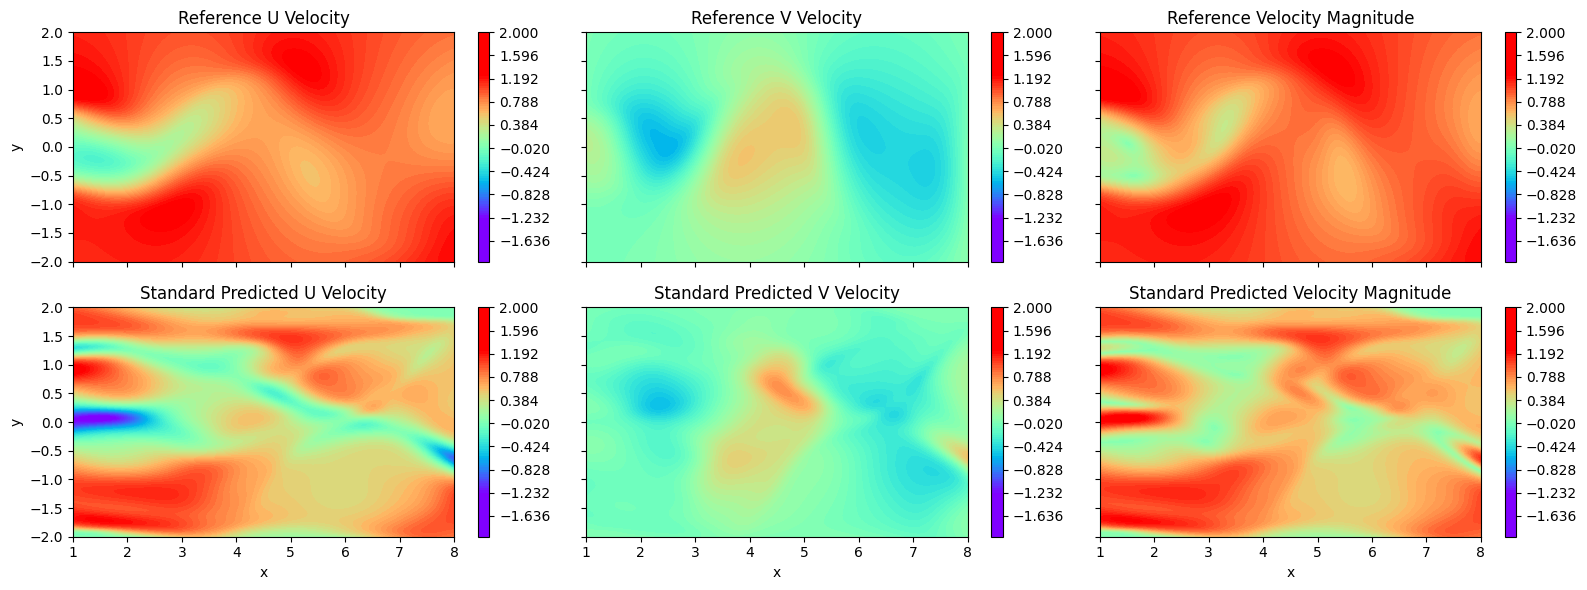

TSA-PINN Model Errors - U: 1.88e-02, V: 4.46e-02


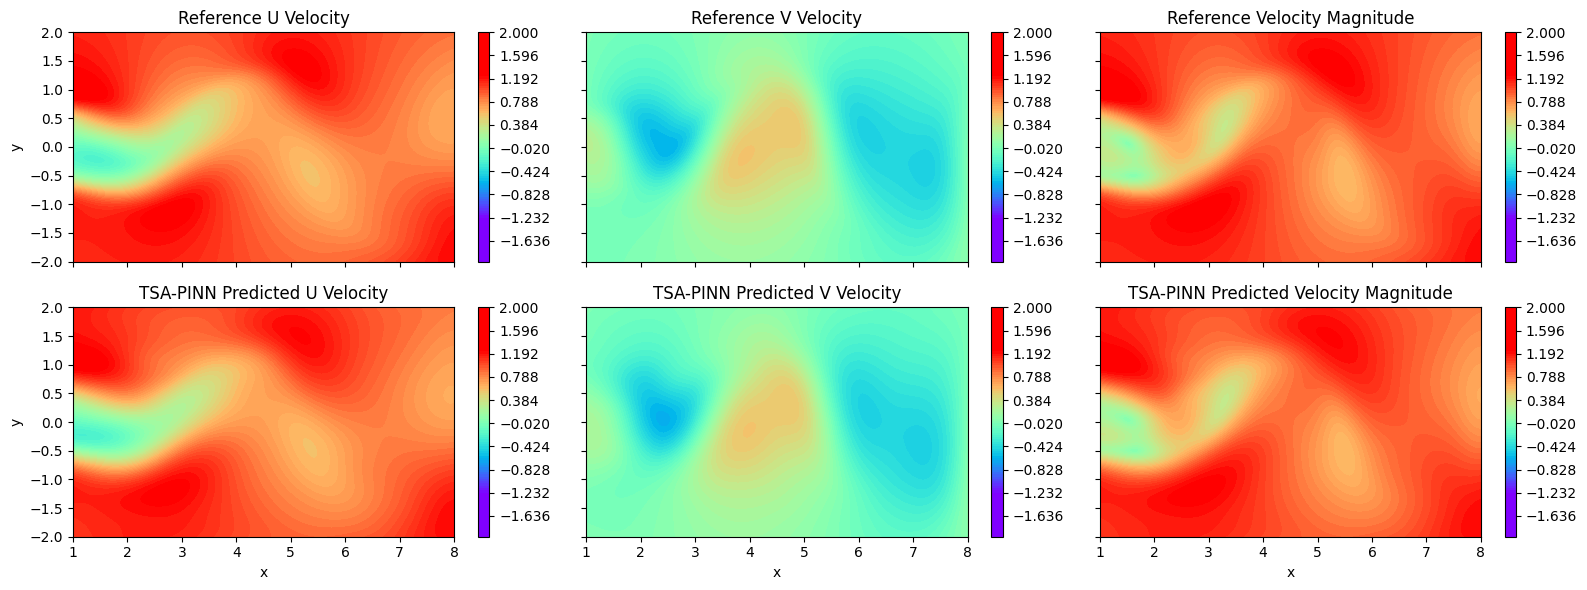

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.colors import Normalize

# Test Data
snap = np.array([100]) # select time frame
x_star = X_star[:,0:1]
y_star = X_star[:,1:2]
t_star = TT[:,snap]
u_star = U_star[:,0,snap]
v_star = U_star[:,1,snap]
p_star = P_star[:,snap]

# convert to tensor
'''x_star = tf.convert_to_tensor(x_star, dtype=dtype)
y_star = tf.convert_to_tensor(y_star, dtype=dtype)
t_star = tf.convert_to_tensor(t_star, dtype=dtype)
u_star = tf.convert_to_tensor(u_star, dtype=dtype)
v_star = tf.convert_to_tensor(v_star, dtype=dtype)
p_star = tf.convert_to_tensor(p_star, dtype=dtype)'''

def evaluate_and_plot(x_star, y_star, t_star, u_star, v_star, p_star, operator, method_name, freq, weights, biases):
    # Compute predictions
    input = tf.concat([x_star, y_star, t_star], axis=1)
    outputs = tf.concat([u_star, v_star], axis=1)
    if method_name == 'TSA-PINN':
        _, _, u_pred, v_pred, _, _, _, _,_ = operator(input, outputs, freq, weights, biases)
    else:
        _, _, u_pred, v_pred, _, _, _ = operator(input, outputs, weights, biases)
    u_pred = u_pred.numpy()
    v_pred = v_pred.numpy()

    # Grid for contour plots
    lb = np.min(x_star), np.min(y_star)
    ub = np.max(x_star), np.max(y_star)
    nn = 200
    grid_x = np.linspace(lb[0], ub[0], nn)
    grid_y = np.linspace(lb[1], ub[1], nn)
    X, Y = np.meshgrid(grid_x, grid_y)

    # Interpolate predictions to grid
    U_pred_grid = griddata((x_star.flatten(), y_star.flatten()), u_pred.flatten(), (X, Y), method='cubic')
    V_pred_grid = griddata((x_star.flatten(), y_star.flatten()), v_pred.flatten(), (X, Y), method='cubic')

    # Interpolate reference data to grid
    U_ref_grid = griddata((x_star.flatten(), y_star.flatten()), u_star.flatten(), (X, Y), method='cubic')
    V_ref_grid = griddata((x_star.flatten(), y_star.flatten()), v_star.flatten(), (X, Y), method='cubic')
    UV_ref = np.sqrt(U_ref_grid**2 + V_ref_grid**2)
    UV_pred = np.sqrt(U_pred_grid**2 + V_pred_grid**2)

    # Calculate errors
    error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
    error_v = np.linalg.norm(v_star - v_pred, 2) / np.linalg.norm(v_star, 2)

    print(f'{method_name} Model Errors - U: {error_u:.2e}, V: {error_v:.2e}')

    # Define color normalization
    norm = Normalize(vmin=-1.25, vmax=1.25)

    # Plotting
    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 6))
    cmaps = 'rainbow'
    contour_opts = {'levels': np.linspace(-2, 2, 100), 'cmap': cmaps}

    # Reference plots
    axs[0, 0].contourf(X, Y, U_ref_grid, **contour_opts, norm=norm)
    axs[0, 0].set_title('Reference U Velocity')
    axs[0, 1].contourf(X, Y, V_ref_grid, **contour_opts, norm=norm)
    axs[0, 1].set_title('Reference V Velocity')
    axs[0, 2].contourf(X, Y, UV_ref, **contour_opts, norm=norm)
    axs[0, 2].set_title('Reference Velocity Magnitude')

    # Predicted plots
    axs[1, 0].contourf(X, Y, U_pred_grid, **contour_opts, norm=norm)
    axs[1, 0].set_title(f'{method_name} Predicted U Velocity')
    axs[1, 1].contourf(X, Y, V_pred_grid, **contour_opts, norm=norm)
    axs[1, 1].set_title(f'{method_name} Predicted V Velocity')
    axs[1, 2].contourf(X, Y, UV_pred, **contour_opts, norm=norm)
    axs[1, 2].set_title(f'{method_name} Predicted Velocity Magnitude')

    for ax in axs.flat:
        ax.set(xlabel='x', ylabel='y')
        ax.label_outer()

    plt.colorbar(axs[0, 0].contourf(X, Y, U_ref_grid, **contour_opts, norm=norm), ax=axs[0, 0])
    plt.colorbar(axs[0, 1].contourf(X, Y, V_ref_grid, **contour_opts, norm=norm), ax=axs[0, 1])
    plt.colorbar(axs[0, 2].contourf(X, Y, UV_ref, **contour_opts, norm=norm), ax=axs[0, 2])
    plt.colorbar(axs[1, 0].contourf(X, Y, U_pred_grid, **contour_opts, norm=norm), ax=axs[1, 0])
    plt.colorbar(axs[1, 1].contourf(X, Y, V_pred_grid, **contour_opts, norm=norm), ax=axs[1, 1])
    plt.colorbar(axs[1, 2].contourf(X, Y, UV_pred, **contour_opts, norm=norm), ax=axs[1, 2])
    # to save
    plt.savefig(f'{method_name} comparison.png', bbox_inches='tight', dpi=300)

    plt.tight_layout()
    plt.show()
# Usage example, assuming operator_standard and operator_FAAF are properly defined elsewhere:
evaluate_and_plot(x_star, y_star, t_star, u_star, v_star, p_star, operator, 'Standard', freq1, weights, biases)
evaluate_and_plot(x_star, y_star, t_star, u_star, v_star, p_star, operator2, 'TSA-PINN', freq2, weights2, biases2)

In [ ]:
# Select a specific spatial point
x_sample = 2  # Example: choose x = 1.0
y_sample = 0  # Example: choose y = -2.0

# Find the index of the spatial point closest to the chosen (x_sample, y_sample)
distances = np.sqrt((XX[:, 0] - x_sample)**2 + (YY[:, 0] - y_sample)**2)
idx_sample_point = np.argmin(distances)  # Find the index of the closest spatial point

# Extract the corresponding x, y values (these should match the chosen (x_sample, y_sample))
x_selected = XX[idx_sample_point, 0]  # x coordinate for the selected point
y_selected = YY[idx_sample_point, 0]  # y coordinate for the selected point

# Extract time steps for all 200 time steps
t_selected = TT[0, :]  # First row of TT contains the time steps (0.0 to 19.9)

# Extract u and v velocity components for the selected spatial point across all time steps
u_selected = UU[idx_sample_point, :]  # u values for the selected spatial point over time
v_selected = VV[idx_sample_point, :]  # v values for the selected spatial point over time

# Convert to TensorFlow tensors (optional, if you need them in TensorFlow format)
x_selected = tf.convert_to_tensor(np.tile(x_selected, (200, 1)), dtype=dtype)  # Repeated x
y_selected = tf.convert_to_tensor(np.tile(y_selected, (200, 1)), dtype=dtype)  # Repeated y
t_selected = tf.convert_to_tensor(t_selected[:, None], dtype=dtype)  # Time steps (reshaped to match dimensions)
u_selected = tf.convert_to_tensor(u_selected[:, None], dtype=dtype)  # u values (reshaped to match dimensions)
v_selected = tf.convert_to_tensor(v_selected[:, None], dtype=dtype)  # v values (reshaped to match dimensions)


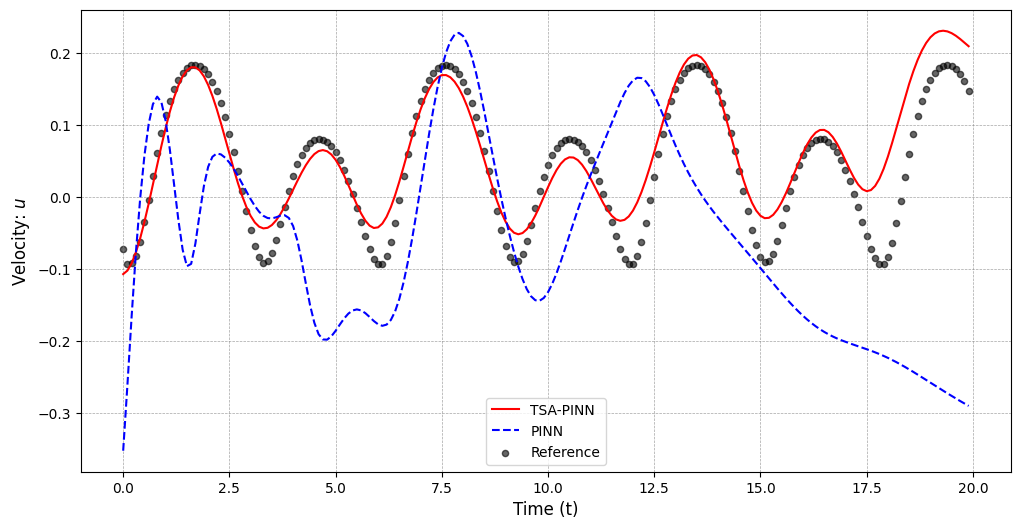

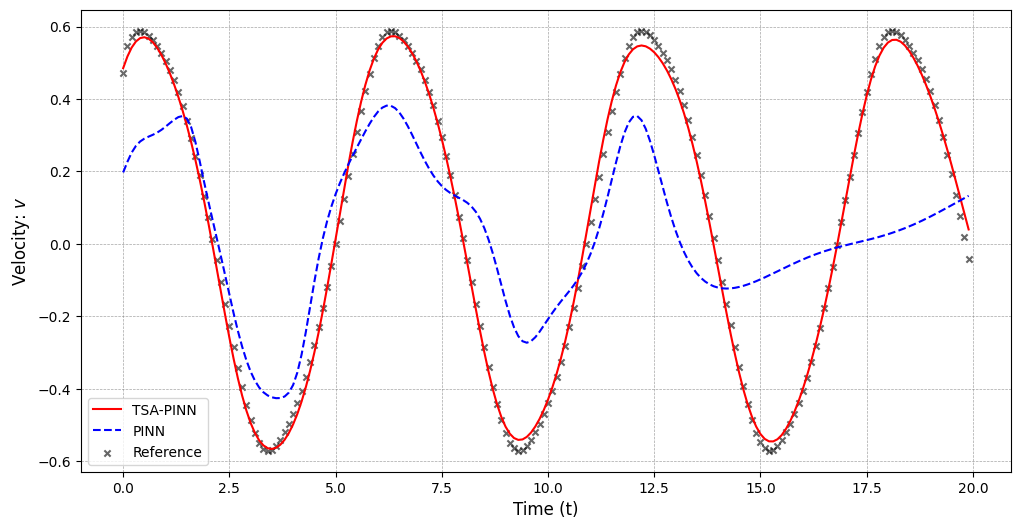

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def plot_velocity_vs_time(layers, x_selected, y_selected, t_selected, u_selected, v_selected, freq, weights, biases, weights_std, biases_std):
    # Prepare the input with the selected (x_selected, y_selected) coordinates and varying time values
    t_input = tf.convert_to_tensor(t_selected, dtype=tf.float64)
    x_input = tf.convert_to_tensor(x_selected, dtype=tf.float64)
    y_input = tf.convert_to_tensor(y_selected, dtype=tf.float64)

    # Stack the inputs (x, y, t) into a single tensor
    inputs = tf.concat([x_input, y_input, t_input], axis=1)

    # Use the operator2 function to get the predicted velocities
    _, _, u_pred, v_pred, _, _, _, _, _ = operator2(inputs, tf.zeros_like(inputs[:, :2]), freq, weights, biases)
    _, _, u_pred_standard, v_pred_standard, _, _, _ = operator(inputs, tf.zeros_like(inputs[:, :2]), weights_std, biases_std)

    # Convert TensorFlow tensors to NumPy arrays for plotting
    u_pred = u_pred.numpy()
    v_pred = v_pred.numpy()
    u_pred_standard = u_pred_standard.numpy()
    v_pred_standard = v_pred_standard.numpy()

    # Separate plot for u-component of velocity
    plt.figure(figsize=(12, 6))

    # Plot the u-component of velocity
    plt.plot(t_selected, u_pred, label='TSA-PINN', color='r', linewidth=1.5)
    plt.plot(t_selected, u_pred_standard, label='PINN', color='b', linewidth=1.5, linestyle='--')
    plt.scatter(t_selected, u_selected, label='Reference', color='black', marker='o', s=20, alpha=0.6)

    plt.xlabel('Time (t)', fontsize=12)
    plt.ylabel('Velocity: $u$', fontsize=12)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.7)

    # Save the plot for the u-component
    plt.savefig('Predicted_vs_Real_u_vs_Time.png', bbox_inches='tight', dpi=300)
    plt.show()

    # Separate plot for v-component of velocity
    plt.figure(figsize=(12, 6))

    # Plot the v-component of velocity
    plt.plot(t_selected, v_pred, label='TSA-PINN', color='r', linewidth=1.5)
    plt.plot(t_selected, v_pred_standard, label='PINN', color='b', linewidth=1.5, linestyle='--')
    plt.scatter(t_selected, v_selected, label='Reference', color='black', marker='x', s=20, alpha=0.6)

    plt.xlabel('Time (t)', fontsize=12)
    plt.ylabel('Velocity: $v$', fontsize=12)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.7)

    # Save the plot for the v-component
    plt.savefig('Predicted_vs_Real_v_vs_Time.png', bbox_inches='tight', dpi=300)
    plt.show()

# Example of how to use this function after the model is trained
# Assume x_selected, y_selected, t_selected, u_selected, v_selected are already defined as before
plot_velocity_vs_time(layers, x_selected, y_selected, t_selected, u_selected, v_selected, freq2, weights2, biases2, weights, biases)
